In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../../Data/BreastCancerWisconsin.csv")
df.drop(columns=['id','Unnamed: 32'], inplace=True)
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [3]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [4]:
y.value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.fit_transform(X_test)

[Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

---

## 📍 K-Nearest Neighbors (KNN) Parameters

### **n_neighbors** `int` *(default = 5)*

Number of neighbors used for prediction:

* Smaller value → More sensitive (can overfit)
* Larger value → Smoother decision boundary

---

### **weights** `{‘uniform’, ‘distance’} or callable` *(default = “uniform”)*

Weight function used in prediction:

* **uniform** → All neighbors have equal weight
* **distance** → Closer neighbors have more influence
* **callable** → Custom function that maps distances → weights

---

### **algorithm** `{‘auto’, ‘ball_tree’, ‘kd_tree’, ‘brute’}` *(default = “auto”)*

Algorithm used to compute nearest neighbors:

* **ball_tree** → Uses BallTree
* **kd_tree** → Uses KDTree
* **brute** → Brute-force search
* **auto** → Automatically selects the best method

> ⚠️ Sparse input always uses **brute force**

---

### **leaf_size** `int` *(default = 30)*

Leaf size for tree-based algorithms:

* Affects **speed** and **memory usage**
* Optimal value depends on dataset

---

### **p** `float` *(default = 2)*

Power parameter for Minkowski distance:

* `p = 1` → Manhattan distance (L1)
* `p = 2` → Euclidean distance (L2)
* Other values → General Minkowski distance

---

### **metric** `str or callable` *(default = “minkowski”)*

Distance metric used:

* Default → Euclidean distance (when `p=2`)
* Other options → From `scipy.spatial.distance`

Special cases:

* **"precomputed"** → Input `X` is a distance matrix
* **callable** → Custom distance function

---

### **metric_params** `dict` *(default = None)*

Additional parameters for the distance metric function

---

### **n_jobs** `int` *(default = None)*

Number of parallel jobs for neighbor search:

* **None** → Single CPU
* **-1** → Use all CPUs

> ⚠️ Does not affect the `fit()` method

---



In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_trf, y_train)
y_pred = knn.predict(X_test_trf)
accuracy_score(y_test, y_pred)

0.956140350877193

In [33]:
from sklearn.model_selection import cross_val_score

def KNeighbourGraph(max_neighbour):
    scaler = StandardScaler()
    
    X_train_trf = scaler.fit_transform(X_train)
    X_test_trf = scaler.transform(X_test)
    
    accuracy_scores = []
    crossValScore = []
    
    for neighbour in range(1, max_neighbour):
        knn = KNeighborsClassifier(n_neighbors=neighbour)
        knn.fit(X_train_trf, y_train)
        y_pred = knn.predict(X_test_trf)
        accuracy_scores.append(accuracy_score(y_test, y_pred))
        
    for neighbour in range(1, max_neighbour):
        crossValScore.append(np.mean(cross_val_score(KNeighborsClassifier(n_neighbors=neighbour),X,y,scoring='accuracy',cv=5)))

    
    fig, ax = plt.subplots(1,2, figsize=(12,6))
    ax[0].plot(range(1,max_neighbour), accuracy_scores)
    ax[0].set_title("Accuracy Score")
    ax[1].plot(range(1,max_neighbour), crossValScore)
    ax[1].set_title("Cross Val Score")
    plt.show()

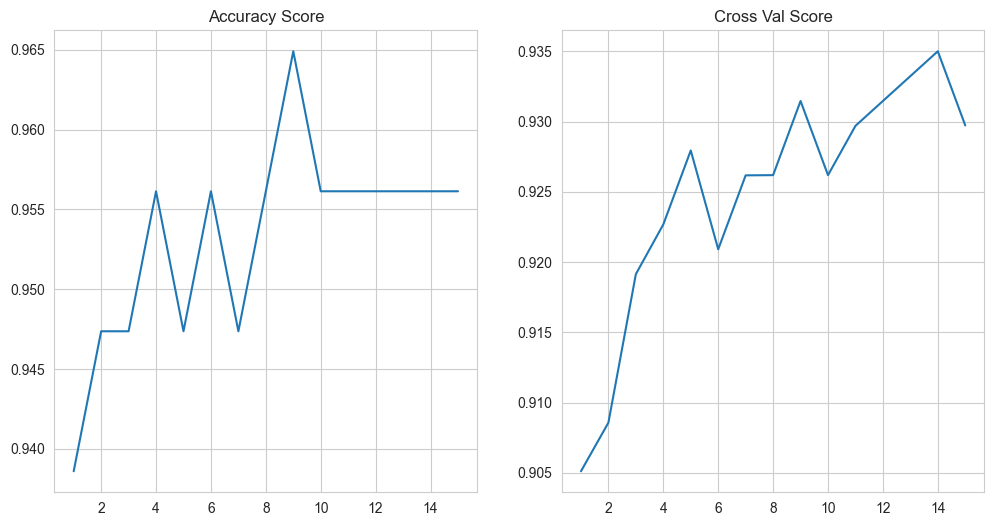

In [34]:
KNeighbourGraph(16)